# Fraud Model Prediction Analysis
Evaluation of `prediction_results.csv`: data checks, metrics, threshold tuning, error analysis.

In [15]:
# 1. Setup & load
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, f1_score, precision_score, recall_score,
                             matthews_corrcoef, brier_score_loss)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.6f}".format)

# --- Option A: upload from your machine (Colab) ---
try:
    from google.colab import files
    uploaded = files.upload()                 # pick prediction_results.csv
    PATH = list(uploaded.keys())[0]
except ImportError:
    PATH = "prediction_results.csv"           # running locally

# --- Option B: from Google Drive (uncomment) ---
# from google.colab import drive; drive.mount("/content/drive")
# PATH = "/content/drive/MyDrive/prediction_results.csv"

df = pd.read_csv(PATH)
print(df.shape)
df.head()

Saving prediction_results.csv to prediction_results (2).csv
(88235, 8)


,transaction_id,actual_fraud,predicted_fraud,prediction_label,prediction_confidence,fraud_probability,legitimate_probability,inference_time_ms
0,0,0,0,LEGITIMATE,0.998698,0.001302,0.998698,0.002297
1,1,0,0,LEGITIMATE,0.999995,0.000005,0.999995,0.002297
2,2,0,0,LEGITIMATE,0.999999,0.000001,0.999999,0.002297
3,3,0,0,LEGITIMATE,0.999996,0.000004,0.999996,0.002297
4,4,0,0,LEGITIMATE,0.999997,0.000003,0.999997,0.002297


## 2. Data quality checks

In [16]:
print(df.dtypes, "\n")
print("Nulls:\n", df.isna().sum(), "\n")
print("Duplicate transaction_ids:", df["transaction_id"].duplicated().sum())

# Consistency checks
print("Prob sum != 1 :", (~np.isclose(df.fraud_probability + df.legitimate_probability, 1)).sum())
print("Label vs predicted_fraud mismatch:",
      (df.prediction_label.eq("FRAUD") != df.predicted_fraud.eq(1)).sum())
print("Prediction != (prob>=0.5):", (df.predicted_fraud != (df.fraud_probability >= 0.5).astype(int)).sum())
print("Confidence != max(prob):",
      (~np.isclose(df.prediction_confidence, df[["fraud_probability","legitimate_probability"]].max(axis=1))).sum())

# Near-constant columns
print("\nUnique values per column:\n", df.nunique())
# NOTE: inference_time_ms is constant -> likely a placeholder, not a real per-row latency measure

print("\nClass balance (actual):")
print(df.actual_fraud.value_counts().to_frame("count").assign(pct=lambda x: x["count"]/len(df)*100))

transaction_id              int64
actual_fraud                int64
predicted_fraud             int64
prediction_label           object
prediction_confidence     float64
fraud_probability         float64
legitimate_probability    float64
inference_time_ms         float64
dtype: object 

Nulls:
 transaction_id            0
actual_fraud              0
predicted_fraud           0
prediction_label          0
prediction_confidence     0
fraud_probability         0
legitimate_probability    0
inference_time_ms         0
dtype: int64 

Duplicate transaction_ids: 0
Prob sum != 1 : 0
Label vs predicted_fraud mismatch: 0
Prediction != (prob>=0.5): 0
Confidence != max(prob): 0

Unique values per column:
 transaction_id            88235
actual_fraud                  2
predicted_fraud               2
prediction_label              2
prediction_confidence      9365
fraud_probability         40632
legitimate_probability     9365
inference_time_ms             1
dtype: int64

Class balance (actual):
   

## 3. Core metrics (default threshold = 0.5)

In [17]:
y_true, y_pred, y_prob = df.actual_fraud, df.predicted_fraud, df.fraud_probability

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}\n")
print(classification_report(y_true, y_pred, target_names=["Legit","Fraud"], digits=4))

summary = {
    "Accuracy": (tp+tn)/len(df),
    "Precision": precision_score(y_true, y_pred),
    "Recall (TPR)": recall_score(y_true, y_pred),
    "F1": f1_score(y_true, y_pred),
    "MCC": matthews_corrcoef(y_true, y_pred),
    "False Positive Rate": fp/(fp+tn),
    "False Negative Rate": fn/(fn+tp),
    "ROC-AUC": roc_auc_score(y_true, y_prob),
    "PR-AUC (Avg Precision)": average_precision_score(y_true, y_prob),
    "Brier score": brier_score_loss(y_true, y_prob),
    "Baseline PR-AUC (prevalence)": y_true.mean(),
}
pd.Series(summary).to_frame("value")

TP=109  FP=7  FN=41  TN=88078

              precision    recall  f1-score   support

       Legit     0.9995    0.9999    0.9997     88085
       Fraud     0.9397    0.7267    0.8195       150

    accuracy                         0.9995     88235
   macro avg     0.9696    0.8633    0.9096     88235
weighted avg     0.9994    0.9995    0.9994     88235



,value
Accuracy,0.999456
Precision,0.939655
Recall (TPR),0.726667
F1,0.819549
MCC,0.826077
False Positive Rate,0.000079
False Negative Rate,0.273333
ROC-AUC,0.994263
PR-AUC (Avg Precision),0.922686
Brier score,0.000377


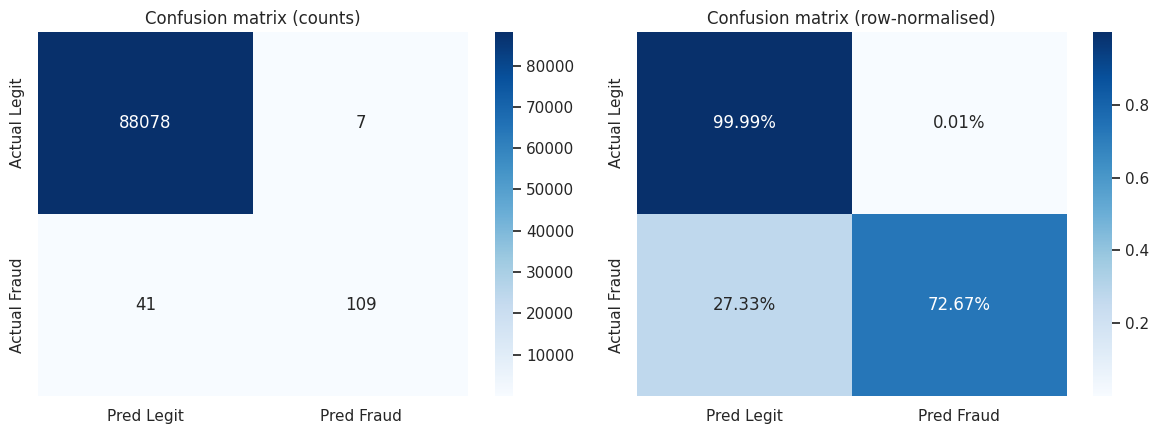

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Pred Legit","Pred Fraud"], yticklabels=["Actual Legit","Actual Fraud"])
ax[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm/cm.sum(axis=1, keepdims=True), annot=True, fmt=".2%", cmap="Blues", ax=ax[1],
            xticklabels=["Pred Legit","Pred Fraud"], yticklabels=["Actual Legit","Actual Fraud"])
ax[1].set_title("Confusion matrix (row-normalised)")
plt.tight_layout(); plt.show()

## 4. ROC & Precision-Recall curves
With ~0.17% fraud, **PR curve matters more than ROC** - ROC-AUC looks great even for weak models.

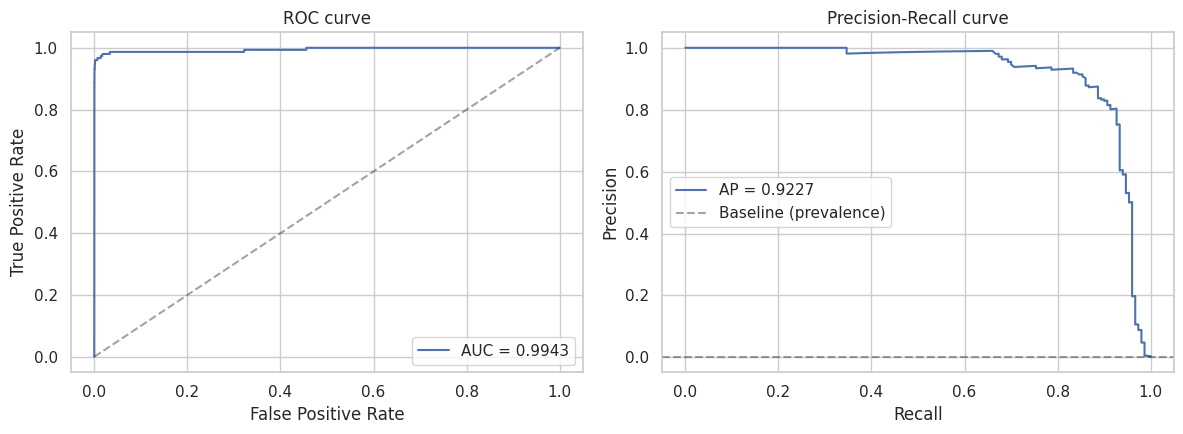

In [19]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
prec, rec, pr_thr = precision_recall_curve(y_true, y_prob)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(fpr, tpr, label=f"AUC = {summary['ROC-AUC']:.4f}")
ax[0].plot([0,1],[0,1],"k--", alpha=.4)
ax[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC curve"); ax[0].legend()

ax[1].plot(rec, prec, label=f"AP = {summary['PR-AUC (Avg Precision)']:.4f}")
ax[1].axhline(y_true.mean(), color="k", ls="--", alpha=.4, label="Baseline (prevalence)")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Probability distributions & calibration

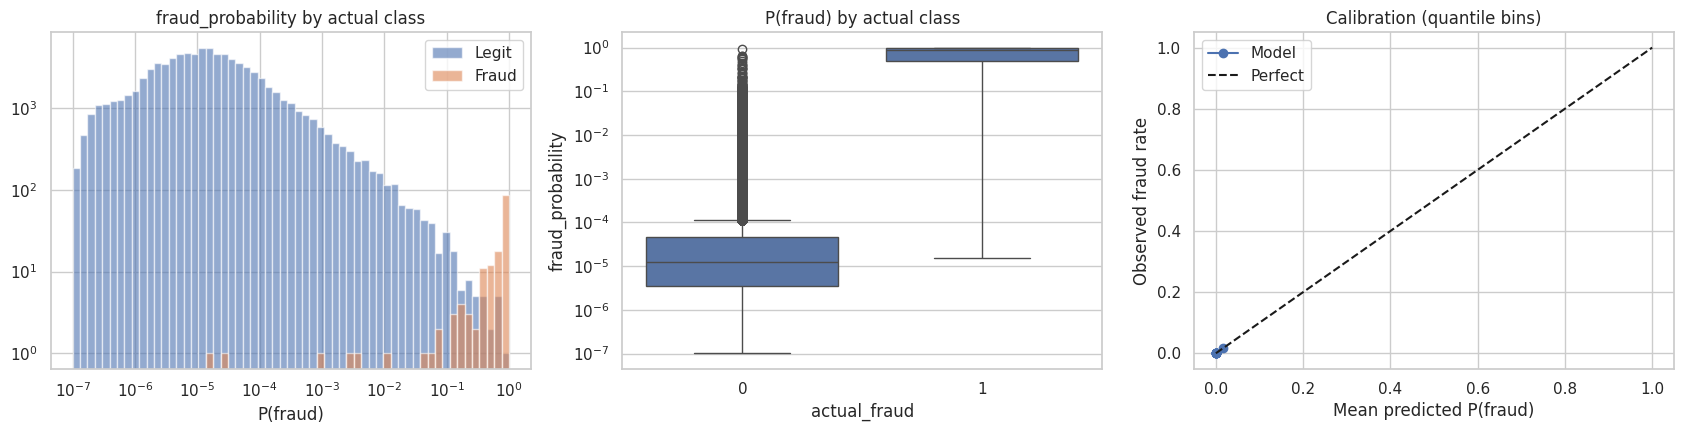

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# Log-scale x reveals separation when most probs are ~0
bins = np.logspace(-7, 0, 60)
for label, name in [(0,"Legit"),(1,"Fraud")]:
    ax[0].hist(df.loc[y_true==label, "fraud_probability"].clip(1e-7), bins=bins, alpha=.6, label=name)
ax[0].set(xscale="log", yscale="log", title="fraud_probability by actual class", xlabel="P(fraud)")
ax[0].legend()

sns.boxplot(data=df, x="actual_fraud", y="fraud_probability", ax=ax[1]); ax[1].set_yscale("log")
ax[1].set_title("P(fraud) by actual class")

frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac_pos, "o-", label="Model"); ax[2].plot([0,1],[0,1],"k--", label="Perfect")
ax[2].set(title="Calibration (quantile bins)", xlabel="Mean predicted P(fraud)", ylabel="Observed fraud rate")
ax[2].legend()
plt.tight_layout(); plt.show()

## 6. Threshold tuning
Default 0.5 is rarely optimal for imbalanced fraud data. Sweep thresholds and pick by F1 or by business cost.

Best F1 threshold:
 threshold       0.340000
precision       0.914286
recall          0.853333
f1              0.882759
TP            128.000000
FP             12.000000
FN             22.000000
TN          88073.000000


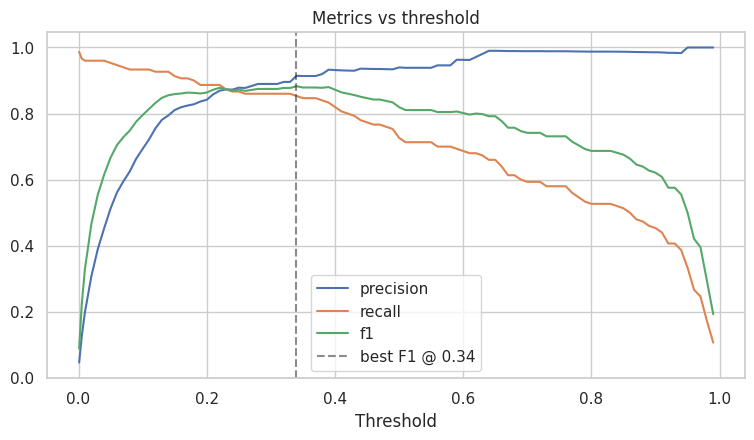

In [21]:
thresholds = np.unique(np.concatenate([np.linspace(0.01, 0.99, 99), [0.001, 0.005, 0.9, 0.95, 0.99]]))
rows = []
for t in thresholds:
    p = (y_prob >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_true, p, labels=[0,1]).ravel()
    rows.append(dict(threshold=t, precision=precision_score(y_true, p, zero_division=0),
                     recall=recall_score(y_true, p), f1=f1_score(y_true, p),
                     TP=tp_, FP=fp_, FN=fn_, TN=tn_))
thr = pd.DataFrame(rows).sort_values("threshold")

best = thr.loc[thr.f1.idxmax()]
print("Best F1 threshold:\n", best.to_string())

plt.figure(figsize=(9,4.5))
for m in ["precision","recall","f1"]:
    plt.plot(thr.threshold, thr[m], label=m)
plt.axvline(best.threshold, color="k", ls="--", alpha=.5, label=f"best F1 @ {best.threshold:.2f}")
plt.xlabel("Threshold"); plt.title("Metrics vs threshold"); plt.legend(); plt.show()

In [22]:
# Cost-based threshold: set your own business costs
COST_FN = 500   # avg loss from a missed fraud (currency units)  <-- EDIT
COST_FP = 10    # cost of reviewing / blocking a legit txn        <-- EDIT

thr["total_cost"] = thr.FN*COST_FN + thr.FP*COST_FP
best_cost = thr.loc[thr.total_cost.idxmin()]
current = thr.iloc[(thr.threshold-0.5).abs().argmin()]
print(f"Cost @0.50        : {current.total_cost:,.0f}")
print(f"Cost @{best_cost.threshold:.2f} (opt) : {best_cost.total_cost:,.0f}")
print(best_cost[["threshold","precision","recall","TP","FP","FN"]].to_string())

Cost @0.50        : 20,570
Cost @0.04 (opt) : 4,740
threshold     0.040000
precision     0.452830
recall        0.960000
TP          144.000000
FP          174.000000
FN            6.000000


## 7. Error analysis

In [23]:
df["outcome"] = np.select(
    [(y_true==1)&(y_pred==1), (y_true==0)&(y_pred==1), (y_true==1)&(y_pred==0)],
    ["TP","FP","FN"], default="TN")

print(df.outcome.value_counts(), "\n")
print("Missed frauds (FN) - what probability did the model give them?")
print(df.loc[df.outcome=="FN","fraud_probability"].describe(), "\n")

# Worst misses & most confident false alarms
display(df[df.outcome=="FN"].nsmallest(10, "fraud_probability")[["transaction_id","fraud_probability","prediction_confidence"]])
display(df[df.outcome=="FP"].nlargest(10, "fraud_probability")[["transaction_id","fraud_probability","prediction_confidence"]])

# Are errors clustered by transaction_id (time / batch drift proxy)?
df["id_bucket"] = pd.qcut(df.transaction_id, 10, labels=False)
by_bucket = df.groupby("id_bucket").agg(n=("actual_fraud","size"), fraud_rate=("actual_fraud","mean"),
                                        pred_rate=("predicted_fraud","mean"),
                                        FN=("outcome", lambda s:(s=="FN").sum()),
                                        FP=("outcome", lambda s:(s=="FP").sum()))
by_bucket

outcome
TN    88078
TP      109
FN       41
FP        7
Name: count, dtype: int64 

Missed frauds (FN) - what probability did the model give them?
count   41.000000
mean     0.266342
std      0.177670
min      0.000015
25%      0.118483
50%      0.257870
75%      0.423966
max      0.497889
Name: fraud_probability, dtype: float64 



,transaction_id,fraud_probability,prediction_confidence
30698,30698,0.000015,0.999985
48942,48942,0.000030,0.999970
38876,38876,0.001045,0.998955
33093,33093,0.002847,0.997153
75906,75906,0.003864,0.996136
6896,6896,0.009836,0.990164
75626,75626,0.046912,0.953088
68116,68116,0.052012,0.947988
12645,12645,0.065203,0.934797
84011,84011,0.073695,0.926305


,transaction_id,fraud_probability,prediction_confidence
17928,17928,0.947794,0.947794
34552,34552,0.639972,0.639972
23549,23549,0.628107,0.628107
79208,79208,0.612645,0.612645
12337,12337,0.588331,0.588331
966,966,0.584328,0.584328
75768,75768,0.555903,0.555903


,n,fraud_rate,pred_rate,FN,FP
id_bucket,,,,,
0,8824,0.001133,0.000793,4,1
1,8823,0.001473,0.001247,3,1
2,8824,0.001587,0.001587,2,2
3,8823,0.001700,0.001473,3,1
4,8824,0.001927,0.001020,8,0
5,8823,0.001813,0.001247,5,0
6,8823,0.001700,0.001473,2,0
7,8824,0.001700,0.001247,4,0
8,8823,0.002493,0.002040,6,2


## 8. Confidence bands & bootstrap CIs

In [24]:
# Precision by predicted-probability band (helps define review tiers)
bands = pd.cut(df.fraud_probability, [0,1e-4,1e-3,1e-2,0.1,0.5,0.9,0.99,1.0], include_lowest=True)
band_tbl = df.groupby(bands, observed=True).agg(n=("actual_fraud","size"), actual_frauds=("actual_fraud","sum"),
                                              fraud_rate=("actual_fraud","mean"))
band_tbl

# Bootstrap 95% CI: with so few positives, point estimates are noisy
rng = np.random.default_rng(42)
B = 500
stats = {"precision":[], "recall":[], "f1":[], "pr_auc":[]}
idx = np.arange(len(df))
for _ in range(B):
    s = rng.choice(idx, len(idx), replace=True)
    yt, yp, pr = y_true.values[s], y_pred.values[s], y_prob.values[s]
    stats["precision"].append(precision_score(yt, yp, zero_division=0))
    stats["recall"].append(recall_score(yt, yp))
    stats["f1"].append(f1_score(yt, yp))
    stats["pr_auc"].append(average_precision_score(yt, pr))
pd.DataFrame({k:[np.mean(v), *np.percentile(v,[2.5,97.5])] for k,v in stats.items()},
             index=["mean","ci_low","ci_high"]).T

,mean,ci_low,ci_high
precision,0.938753,0.892092,0.974900
recall,0.726457,0.656146,0.795921
f1,0.818525,0.764359,0.867850
pr_auc,0.921524,0.880821,0.954195


## 9. Export results

In [25]:
df.to_csv("prediction_results_annotated.csv", index=False)
thr.to_csv("threshold_sweep.csv", index=False)
try:
    from google.colab import files
    files.download("prediction_results_annotated.csv"); files.download("threshold_sweep.csv")
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>